Question 4

Section (a) - Otsu thesholding.

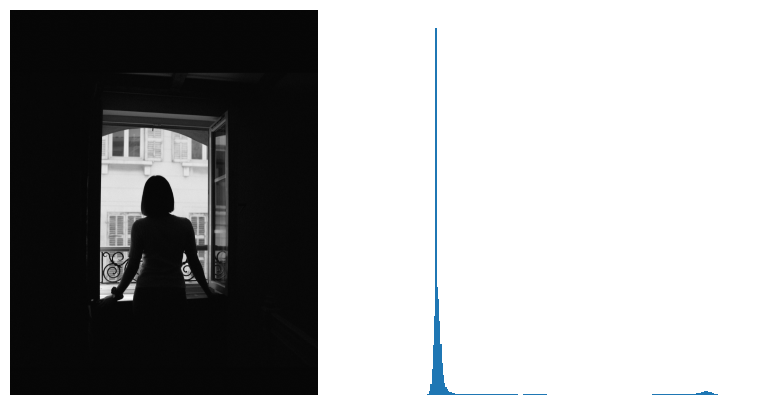

In [11]:
#Load image convert to gray scale and show the histogram
import cv2 as cv
import numpy as np
import sys
import matplotlib.pyplot as plt

img = cv.imread('woman_standing.jpg')
if img is None:
    print("Could not read input image")
    sys.exit(1)

# Convert iamge to gray scale and show  the initial histogram
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plot, axis = plt.subplots(1,2,figsize=(10,5))
axis[0].imshow(img_gray, cmap='gray')
axis[0].axis('off')
axis[1].hist(img_gray.flatten(),bins=256,range=[0,256])
axis[1].axis('off')
plt.show()

Otsu Threshold Value: 101.0


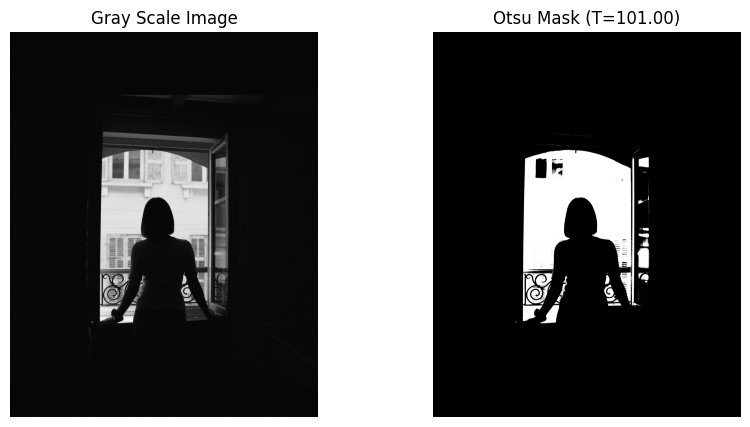

In [24]:
# Apply Otsu thresholding
threshold, mask = cv.threshold(
    img_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
)

print("Otsu Threshold Value:", threshold)

plot, axis = plt.subplots(1,2,figsize=(10,5))
axis[0].imshow(img_gray, cmap='gray')
axis[0].axis('off')
axis[0].set_title('Gray Scale Image')
axis[1].imshow(mask, cmap='gray')
axis[1].set_title(f'Otsu Mask (T={threshold:.2f})')
axis[1].axis('off')
plt.show()

Section (b)

(24982364,)
(5867, 4693)


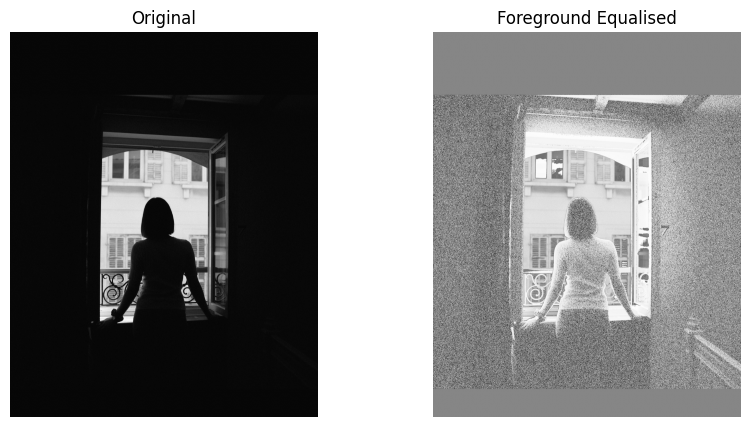

In [ ]:
foreground_pixels = img_gray[mask == 0]

#Do histogram equalization only for foreground
hist = np.bincount(foreground_pixels, minlength=256)
cdf = hist.cumsum()

cdf_min = cdf[cdf > 0].min()
total = foreground_pixels.size

cdf_norm = (cdf - cdf_min) / (total - cdf_min) * 255
cdf_norm_lut = cdf_norm.astype(np.uint8)

result = img_gray.copy()
result[mask == 0] = cdf_norm_lut[img_gray[mask == 0]]

plot, axis = plt.subplots(1,2,figsize=(10,5))
axis[0].imshow(img_gray, cmap='gray')
axis[0].axis('off')
axis[0].set_title('Original')
axis[1].imshow(result, cmap='gray')
axis[1].set_title('Foreground Equalised')
axis[1].axis('off')
plt.show()